In [1]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import random
import gdown
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url = 'https://drive.google.com/uc?id=1XKJdlxS_kkupTTB7UijAzIUdYd7RALMf'
output = '/content/drive/MyDrive/Medical_Image/vae.pth'

gdown.download(url, output, quiet=False)



Downloading...
From (original): https://drive.google.com/uc?id=1XKJdlxS_kkupTTB7UijAzIUdYd7RALMf
From (redirected): https://drive.google.com/uc?id=1XKJdlxS_kkupTTB7UijAzIUdYd7RALMf&confirm=t&uuid=f3deb91e-d323-493d-9693-55ec2758077d
To: /content/drive/MyDrive/Medical_Image/vae.pth
100%|██████████| 205M/205M [00:01<00:00, 126MB/s]


'/content/drive/MyDrive/Medical_Image/vae.pth'

In [4]:
# https://drive.google.com/file/d/166YCzwjZJWSveox3T3R7OKcSXymK2UIW/view?usp=sharing
url = 'https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW'  # synthrad
#url = 'https://drive.google.com/uc?id=1z2aylSCAqHuLAlsz7s6A6I9ufUthX280' # Harvard
#url = 'https://drive.google.com/uc?id=1Wrg3ZRCroPrm1j-3DNQB4-lLkjca3AGF'

output = 'medical_image_data.zip'

gdown.download(url, output, quiet=False)

try:
   os.makedirs('/content/data')
except FileExistsError:
  pass

try:
   os.makedirs('/content/medical_image_data')
except FileExistsError:
  pass

!unzip /content/medical_image_data.zip -d /content/data/medical_image_data/

Downloading...
From (original): https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW
From (redirected): https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW&confirm=t&uuid=8d8e51c9-d4a2-4ebf-9ca0-84e52cfaf400
To: /content/medical_image_data.zip
100%|██████████| 185M/185M [00:03<00:00, 57.0MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1287.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3905.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2615.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1748.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2998.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1833.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/4879.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2414.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/0335.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3576.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/0063.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/4210.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1570.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3819.png

In [5]:
!git clone https://github.com/explainingai-code/StableDiffusion-PyTorch.git

import shutil
import os

src = "/content/StableDiffusion-PyTorch"
dst = "/content/"

# Make sure destination exists
os.makedirs(dst, exist_ok=True)

# Copy everything from src to dst
for item in os.listdir(src):
    s = os.path.join(src, item)
    d = os.path.join(dst, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)  # requires Python 3.8+
    else:
        shutil.copy2(s, d)


Cloning into 'StableDiffusion-PyTorch'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 151 (delta 39), reused 29 (delta 29), pack-reused 99 (from 3)
Receiving objects: 100% (151/151), 69.82 KiB | 581.00 KiB/s, done.
Resolving deltas: 100% (78/78), done.


In [16]:
!mkdir -p /content/data/medical_image_data
!mkdir -p /content/data/medical_image_data
!cp /content/vgg.pth /content/models/weights/v0.1

In [7]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import cv2
import PIL


def flip_augment_images(image):
    augmented_images = []


    horizontal_flip = image.transpose(Image.FLIP_LEFT_RIGHT)
    vertical_flip = image.transpose(Image.FLIP_TOP_BOTTOM)
    both_flips = image.transpose(Image.ROTATE_180)

    augmented_images += [image, horizontal_flip, vertical_flip, both_flips]

    return augmented_images


def patch_augment_images(image):

    w, h = image.size
    image1 = image.copy().crop((0, 0, w*2//3, h*2//3))
    image2 = image.copy().crop((w//3, h//3, w, h))
    image3 = image.copy().crop((w//3, 0, w, h*2//3))
    image4 = image.copy().crop((0, h//3, w*2//3, h))

    return [image, image1, image2, image3, image4]



#DATASET_PATH = '/content/MyDatasets/CT-MRI/train/'

import os
from PIL import Image

directory_path_MRI = '/content/data/medical_image_data/CT-MRI/MRI'
directory_path_CT = '/content/data/medical_image_data/CT-MRI/CT'

MRI_images = []
CT_images = []

for filename in os.listdir(directory_path_MRI):
    file_path_MRI = os.path.join(directory_path_MRI, filename)
    file_path_CT = os.path.join(directory_path_CT, filename)

    if os.path.isfile(file_path_MRI) and os.path.isfile(file_path_CT):
        try:
            mri = Image.open(file_path_MRI)
            ct = Image.open(file_path_CT)

            #MRI_images += flip_augment_images(patch_augment_images(mri))
            #CT_images += flip_augment_images(patch_augment_images(ct))

            #MRI_images += flip_augment_images(mri)
            #CT_images += flip_augment_images(ct)

            MRI_images.append(mri)
            CT_images.append(ct)

        except IOError as e:
            print(f"Error loading '{filename}': {e}")


print(len(MRI_images))

5078


5078
Training samples: 4062
Validation samples: 1016


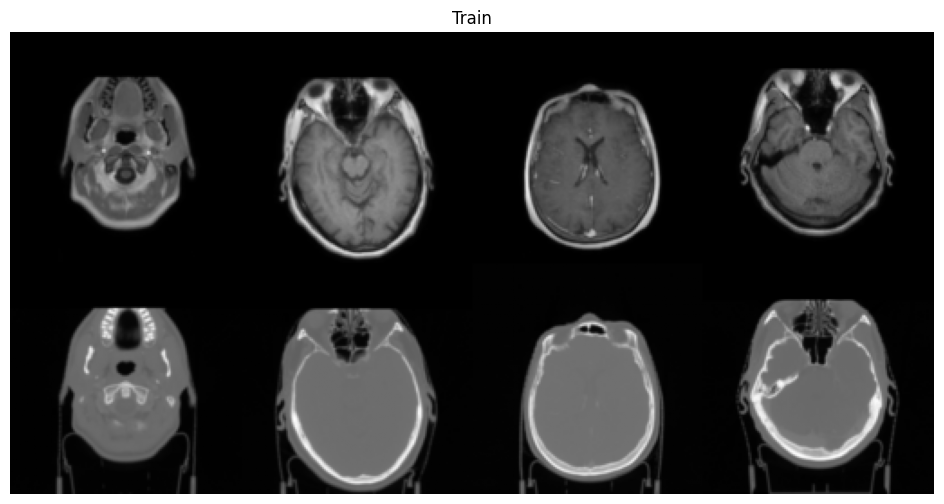

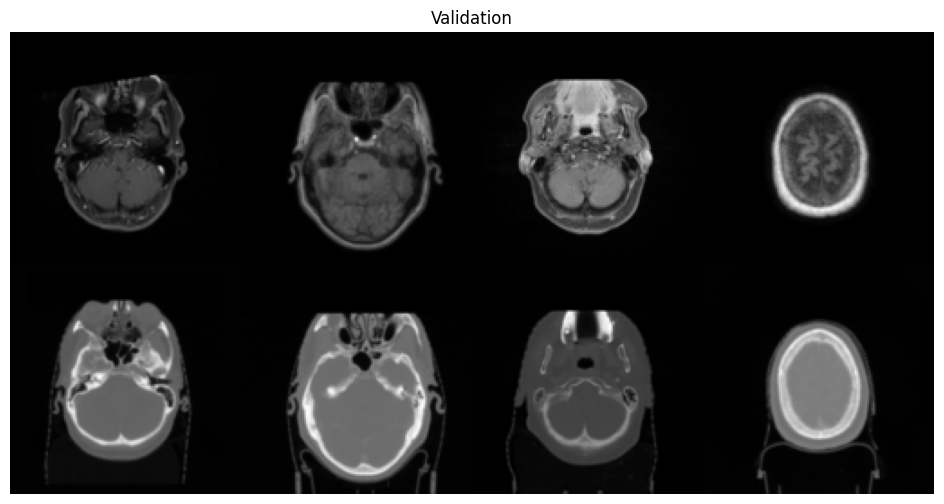

In [8]:
from torchvision import transforms
from torch.utils.data import DataLoader, Subset



# Custom dataset
class MedicalImageDataset(Dataset):
    def __init__(self, x_list, y_list, transform=None):
        assert len(x_list) == len(y_list), "x and y must have the same length"
        self.x_list = x_list
        self.y_list = y_list

    def __len__(self):
        return len(self.x_list)

    def __getitem__(self, idx):
        x = self.x_list[idx]
        y = self.y_list[idx]

        return x, y


def load_transformed_dataset():
    data_transforms = [
        transforms.Grayscale(num_output_channels=1),  # convert to grayscale
        transforms.Resize((128, 128)),
        #transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1)  # scale to [-1, 1]
    ]
    return transforms.Compose(data_transforms)



def plot_images(images_x, images_y, title):
    plt.figure(figsize=(16, 6))
    plt.imshow(torch.cat([torch.cat([i for i in images_x], dim=-1),
                          torch.cat([i for i in images_y], dim=-1)], dim=-2).permute(1, 2, 0).cpu(), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()


BATCH_SIZE = 4
VAL_SPLIT = 0.2

print(len(MRI_images))

transform = load_transformed_dataset()

transformed_data_MRI = [transform(img) for img in MRI_images]
transformed_data_CT = [transform(img) for img in CT_images]

# Full dataset
full_dataset = MedicalImageDataset(transformed_data_MRI, transformed_data_CT)

# Sequential split: first 80% train, last 20% validation
dataset_size = len(full_dataset)
split_idx = int(dataset_size * (1 - VAL_SPLIT))

train_dataset = Subset(full_dataset, range(0, split_idx))
val_dataset = Subset(full_dataset, range(split_idx, dataset_size))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,      # shuffle only during training
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize
batch_x, batch_y = next(iter(train_loader))
plot_images(batch_x[:8], batch_y[:8], title='Train')

batch_x_val, batch_y_val = next(iter(val_loader))
plot_images(batch_x_val[:8], batch_y_val[:8], title='Validation')


In [9]:
yaml_path = "/content/config/medical_image.yaml"

# Example content to write
yaml_content = f"""
dataset_params:
  im_path: '/content/data/medical_image_data'
  im_channels : 1
  im_size : 128
  name: 'medical_image'

diffusion_params:
  num_timesteps : 1000
  beta_start : 0.0015
  beta_end : 0.0195

ldm_params:
  down_channels: [ 256, 384, 512, 768 ]
  mid_channels: [ 768, 512 ]
  down_sample: [ True, True, True ]
  attn_down : [True, True, True]
  time_emb_dim: 512
  norm_channels: 32
  num_heads: 16
  conv_out_channels : 128
  num_down_layers : 2
  num_mid_layers : 2
  num_up_layers : 2

autoencoder_params:
  z_channels: 4
  codebook_size : 8192
  down_channels : [64, 128, 256, 256]
  mid_channels : [256, 256]
  down_sample : [True, True, False]
  attn_down : [False, False, False]
  norm_channels: 32
  num_heads: 4
  num_down_layers : 2
  num_mid_layers : 2
  num_up_layers : 2

train_params:
  seed : 1111
  task_name: 'mnist'
  ldm_batch_size: {BATCH_SIZE}
  autoencoder_batch_size: {BATCH_SIZE}
  disc_start: 15000
  disc_weight: 0.5
  codebook_weight: 1
  commitment_beta: 0.2
  perceptual_weight: 1
  kl_weight: 0.000005
  ldm_epochs: 100
  autoencoder_epochs: 10
  num_samples: {BATCH_SIZE}
  num_grid_rows: 4
  ldm_lr: 0.000005
  autoencoder_lr: 0.00001
  autoencoder_acc_steps: 4
  autoencoder_img_save_steps: 64
  save_latents : False
  vae_latent_dir_name: 'vae_latents'
  vqvae_latent_dir_name: 'vqvae_latents'
  ldm_ckpt_name: 'ddpm_ckpt.pth'
  vqvae_autoencoder_ckpt_name: 'vqvae_autoencoder_ckpt.pth'
  vae_autoencoder_ckpt_name: 'vae_autoencoder_ckpt.pth'
  vqvae_discriminator_ckpt_name: 'vqvae_discriminator_ckpt.pth'
  vae_discriminator_ckpt_name: 'vae_discriminator_ckpt.pth'
"""

# Overwrite the file
with open(yaml_path, "w") as f:
    f.write(yaml_content)


In [10]:
import torch
import torch.nn as nn
from models.blocks import DownBlock, MidBlock, UpBlock


class VQVAE(nn.Module):
    def __init__(self, im_channels, model_config):
        super().__init__()
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        # To disable attention in Downblock of Encoder and Upblock of Decoder
        self.attns = model_config['attn_down']

        # Latent Dimension
        self.z_channels = model_config['z_channels']
        self.codebook_size = model_config['codebook_size']
        self.norm_channels = model_config['norm_channels']
        self.num_heads = model_config['num_heads']

        # Assertion to validate the channel information
        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-1]
        assert len(self.down_sample) == len(self.down_channels) - 1
        assert len(self.attns) == len(self.down_channels) - 1

        # Wherever we use downsampling in encoder correspondingly use
        # upsampling in decoder
        self.up_sample = list(reversed(self.down_sample))

        ##################### Encoder ######################
        self.encoder_conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))

        # Downblock + Midblock
        self.encoder_layers = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.encoder_layers.append(DownBlock(self.down_channels[i], self.down_channels[i + 1],
                                                 t_emb_dim=None, down_sample=self.down_sample[i],
                                                 num_heads=self.num_heads,
                                                 num_layers=self.num_down_layers,
                                                 attn=self.attns[i],
                                                 norm_channels=self.norm_channels))

        self.encoder_mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.encoder_mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i + 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.encoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[-1])
        self.encoder_conv_out = nn.Conv2d(self.down_channels[-1], self.z_channels, kernel_size=3, padding=1)

        # Pre Quantization Convolution
        self.pre_quant_conv = nn.Conv2d(self.z_channels, self.z_channels, kernel_size=1)

        # Codebook
        self.embedding = nn.Embedding(self.codebook_size, self.z_channels)
        ####################################################

        ##################### Decoder ######################

        # Post Quantization Convolution
        self.post_quant_conv = nn.Conv2d(self.z_channels*2, self.z_channels, kernel_size=1)
        self.decoder_conv_in = nn.Conv2d(self.z_channels*2, self.mid_channels[-1], kernel_size=3, padding=(1, 1))

        # Midblock + Upblock
        self.decoder_mids = nn.ModuleList([])
        for i in reversed(range(1, len(self.mid_channels))):
            self.decoder_mids.append(MidBlock(self.mid_channels[i]*2, self.mid_channels[i - 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.decoder_layers = nn.ModuleList([])
        for i in reversed(range(1, len(self.down_channels))):
            self.decoder_layers.append(UpBlock(self.down_channels[i]*2, self.down_channels[i - 1],
                                               t_emb_dim=None, up_sample=self.down_sample[i - 1],
                                               num_heads=self.num_heads,
                                               num_layers=self.num_up_layers,
                                               attn=self.attns[i-1],
                                               norm_channels=self.norm_channels))

        self.decoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[0])
        self.decoder_conv_out = nn.Conv2d(2*self.down_channels[0], im_channels, kernel_size=3, padding=1)

    def quantize(self, x):
        B, C, H, W = x.shape

        # B, C, H, W -> B, H, W, C
        x = x.permute(0, 2, 3, 1)

        # B, H, W, C -> B, H*W, C
        x = x.reshape(x.size(0), -1, x.size(-1))

        # Find nearest embedding/codebook vector
        # dist between (B, H*W, C) and (B, K, C) -> (B, H*W, K)
        dist = torch.cdist(x, self.embedding.weight[None, :].repeat((x.size(0), 1, 1)))
        # (B, H*W)
        min_encoding_indices = torch.argmin(dist, dim=-1)

        # Replace encoder output with nearest codebook
        # quant_out -> B*H*W, C
        quant_out = torch.index_select(self.embedding.weight, 0, min_encoding_indices.view(-1))

        # x -> B*H*W, C
        x = x.reshape((-1, x.size(-1)))
        commmitment_loss = torch.mean((quant_out.detach() - x) ** 2)
        codebook_loss = torch.mean((quant_out - x.detach()) ** 2)
        quantize_losses = {
            'codebook_loss': codebook_loss,
            'commitment_loss': commmitment_loss
        }
        # Straight through estimation
        quant_out = x + (quant_out - x).detach()

        # quant_out -> B, C, H, W
        quant_out = quant_out.reshape((B, H, W, C)).permute(0, 3, 1, 2)
        min_encoding_indices = min_encoding_indices.reshape((-1, quant_out.size(-2), quant_out.size(-1)))
        return quant_out, quantize_losses, min_encoding_indices

    def encode(self, x):

        out = self.encoder_conv_in(x)
        y = [out]

        #print(len(y), 'y')

        for idx, down in enumerate(self.encoder_layers):
            out = down(out)
            y.append(out)
        for mid in self.encoder_mids:
            out = mid(out)
            y.append(out)

        out = self.encoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.encoder_conv_out(out)
        y.append(out)
        out = self.pre_quant_conv(out)
        y.append(out)
        out, quant_losses, _ = self.quantize(out)

        #print(len(y), 'y')

        return out, y, quant_losses

    def decode(self, z, y):
        out = z

        out = self.post_quant_conv(torch.cat((out, y[-1]), 1))

        out = self.decoder_conv_in(torch.cat((out, y[-2]), 1))
        for idx, mid in  enumerate(self.decoder_mids):
            out = mid(torch.cat((out, y[-3-idx]), 1))
        for idx, up in enumerate(self.decoder_layers):
            out = up(torch.cat((out, y[-3-len(self.decoder_mids)-idx]), 1))

        out = self.decoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.decoder_conv_out(torch.cat((out, y[0]), 1))
        #out = self.decoder_conv_out(out)
        return out

    #def forward(self, x):
     #   pass
        #return out, z, quant_losses



class XVQ_VAE(nn.Module):
    def __init__(self, im_channels, model_config):
        super().__init__()

        self.vae1 = VQVAE(
            im_channels=im_channels,
            model_config=model_config
        )

        self.vae2 = VQVAE(
            im_channels=im_channels,
            model_config=model_config
        )

        self.swap_prob = 0.5

    def swap_shared_latents(self, z1, z2):
        """
        z1, z2: [B, C, H, W]

        First half of channels = shared
        Second half = private

        Randomly, for each paired MRI/CT sample:
            MRI decoder uses CT shared + MRI private
            CT decoder uses MRI shared + CT private
        """

        C = z1.shape[1]

        assert C % 2 == 0, (
            "z_channels must be even to split latent in half"
        )

        half = C // 2

        # split into shared/private parts
        s1 = z1[:, :half]
        p1 = z1[:, half:]

        s2 = z2[:, :half]
        p2 = z2[:, half:]

        if self.training:
            # one independent swap decision per paired sample
            swap_mask = (
                torch.rand(
                    z1.shape[0], 1, 1, 1,
                    device=z1.device
                ) < self.swap_prob
            )

            s1_dec = torch.where(
                swap_mask,
                s2,
                s1
            )

            s2_dec = torch.where(
                swap_mask,
                s1,
                s2
            )

        else:
            # no random swapping during validation/inference
            s1_dec = s1
            s2_dec = s2

        z1_dec = torch.cat(
            [s1_dec, p1],
            dim=1
        )

        z2_dec = torch.cat(
            [s2_dec, p2],
            dim=1
        )

        return z1_dec, z2_dec


    def forward(self, x1, x2):

        z1, y1, quant_losses1 = self.vae1.encode(x1)
        z2, y2, quant_losses2 = self.vae2.encode(x2)

        # ----------------------------
        # NEW: shared latent swapping
        # ----------------------------
        z1_dec, z2_dec = self.swap_shared_latents(
            z1,
            z2
        )

        # Keep your current cross-modal skip conditioning
        out1 = self.vae1.decode(
            z1_dec,
            y2
        )

        out2 = self.vae2.decode(
            z2_dec,
            y1
        )

        return (
            out1,
            out2,
            z1,
            z2,
            quant_losses1,
            quant_losses2
        )

In [11]:
import yaml
import argparse
import torch
import random
import torchvision
import os
import numpy as np
from tqdm import tqdm
#from models.vqvae import VQVAE
from models.lpips import LPIPS
from models.discriminator import Discriminator
from torch.utils.data.dataloader import DataLoader
from dataset.mnist_dataset import MnistDataset
from dataset.celeb_dataset import CelebDataset
from torch.optim import Adam
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def train(args, data_loader):
    load_model = True

    # Read the config file #
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)

    dataset_config = config['dataset_params']
    autoencoder_config = config['autoencoder_params']
    train_config = config['train_params']

    # Set the desired seed value #
    seed = train_config['seed']
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device == 'cuda':
        torch.cuda.manual_seed_all(seed)
    #############################

    # Create the model and dataset #
    #model = VQVAE(im_channels=dataset_config['im_channels'],
    #              model_config=autoencoder_config).to(device)
    model = XVQ_VAE(im_channels=dataset_config['im_channels'],
                  model_config=autoencoder_config).to(device)

    if load_model:
      model.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/vae.pth',
                                       map_location=device), strict=True)


    """
    # Create the dataset
    im_dataset_cls = {
        'mnist': MnistDataset,
        'celebhq': CelebDataset,
    }.get(dataset_config['name'])


    im_dataset = im_dataset_cls(split='train',
                                im_path=dataset_config['im_path'],
                                im_size=dataset_config['im_size'],
                                im_channels=dataset_config['im_channels'])

    data_loader = DataLoader(im_dataset,
                             batch_size=train_config['autoencoder_batch_size'],
                             shuffle=True)
    """

    # Create output directories
    if not os.path.exists(train_config['task_name']):
        os.mkdir(train_config['task_name'])

    num_epochs = train_config['autoencoder_epochs']

    # L1/L2 loss for Reconstruction
    recon_criterion = torch.nn.MSELoss()
    # Disc Loss can even be BCEWithLogits
    disc_criterion = torch.nn.MSELoss()

    # No need to freeze lpips as lpips.py takes care of that
    lpips_model = LPIPS().eval().to(device)
    discriminator = Discriminator(im_channels=dataset_config['im_channels']).to(device)

    if load_model:
        discriminator.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/discriminator.pth',
                                       map_location=device), strict=True)


    optimizer_d = Adam(discriminator.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))
    optimizer_g = Adam(model.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))

    disc_step_start = train_config['disc_start']
    step_count = 0

    # This is for accumulating gradients incase the images are huge
    # And one cant afford higher batch sizes
    acc_steps = train_config['autoencoder_acc_steps']
    image_save_steps = train_config['autoencoder_img_save_steps']
    img_save_count = 0

    for epoch_idx in range(num_epochs):
        recon_losses = []
        codebook_losses = []
        #commitment_losses = []
        perceptual_losses = []
        disc_losses = []
        gen_losses = []
        losses = []

        optimizer_g.zero_grad()
        optimizer_d.zero_grad()

        for im1, im2 in tqdm(data_loader):
            step_count += 1
            im1 = im1.float().to(device)
            im2 = im2.float().to(device)

            # Fetch autoencoders output(reconstructions)
            #model_output = model(im)
            #output, z, quantize_losses = model_output
            out1, out2, z1, z2, quant_losses1, quant_losses2 = model(im1, im2)

            half = z1.shape[1] // 2

            shared_z1 = z1[:, :half]
            shared_z2 = z2[:, :half]

            shared_loss = torch.nn.functional.smooth_l1_loss(
                shared_z1,
                shared_z2
            )
            #print(out1.shape)

            # Image Saving Logic
            if step_count % image_save_steps == 0 or step_count == 1:
                sample_size = min(8, im2.shape[0])
                save_output = torch.clamp(out2[:sample_size], -1., 1.).detach().cpu()
                save_output = ((save_output + 1) / 2)
                save_input = ((im2[:sample_size] + 1) / 2).detach().cpu()

                grid = make_grid(torch.cat([save_input, save_output], dim=0), nrow=sample_size)
                img = torchvision.transforms.ToPILImage()(grid)
                if not os.path.exists(os.path.join(train_config['task_name'],'vqvae_autoencoder_samples')):
                    os.mkdir(os.path.join(train_config['task_name'], 'vqvae_autoencoder_samples'))
                img.save(os.path.join(train_config['task_name'],'vqvae_autoencoder_samples',
                                      'current_autoencoder_sample_{}.png'.format(img_save_count)))
                img_save_count += 1
                img.close()

            ######### Optimize Generator ##########
            # L2 Loss
            recon_loss1 = recon_criterion(out1, im1)
            recon_loss2 = recon_criterion(out2, im2)
            recon_loss = (recon_loss1 + recon_loss2) / 2

            recon_losses.append(recon_loss.item())
            recon_loss = recon_loss / acc_steps

            shared_weight = 0.01

            g_loss = (recon_loss +
                      (train_config['codebook_weight'] * (quant_losses1['codebook_loss'] + quant_losses2['codebook_loss']) / 2  / acc_steps) +
                      (train_config['commitment_beta'] * (quant_losses1['commitment_loss'] + quant_losses2['commitment_loss']) / 2 / acc_steps) +
                        shared_weight * shared_loss / acc_steps)

            codebook_losses.append(train_config['codebook_weight'] * (quant_losses1['codebook_loss'] + quant_losses2['codebook_loss']).item() / 2)
            # Adversarial loss only if disc_step_start steps passed
            if step_count > disc_step_start:
                disc_fake_pred1 = discriminator(out1)
                disc_fake_loss1 = disc_criterion(disc_fake_pred1,
                                                torch.ones(disc_fake_pred1.shape,
                                                           device=disc_fake_pred1.device))

                disc_fake_pred2 = discriminator(out2)
                disc_fake_loss2 = disc_criterion(disc_fake_pred2,
                                                torch.ones(disc_fake_pred2.shape,
                                                           device=disc_fake_pred2.device))

                disc_fake_loss = (disc_fake_loss1 + disc_fake_loss2) / 2

                gen_losses.append(train_config['disc_weight'] * disc_fake_loss.item())
                g_loss += train_config['disc_weight'] * disc_fake_loss / acc_steps
            lpips_loss = (torch.mean(lpips_model(out1, im1)) + torch.mean(lpips_model(out2, im2)))/2

            perceptual_losses.append(train_config['perceptual_weight'] * lpips_loss.item())
            g_loss += train_config['perceptual_weight']*lpips_loss / acc_steps
            losses.append(g_loss.item())
            g_loss.backward()
            #####################################

            ######### Optimize Discriminator #######
            if step_count > disc_step_start:
                fake1 = out1
                fake2 = out2
                disc_fake_pred1 = discriminator(fake1.detach())
                disc_fake_pred2 = discriminator(fake2.detach())
                disc_real_pred1 = discriminator(im1)
                disc_real_pred2 = discriminator(im2)
                disc_fake_loss1 = disc_criterion(disc_fake_pred1,
                                                torch.zeros(disc_fake_pred1.shape,
                                                            device=disc_fake_pred1.device))
                disc_fake_loss2 = disc_criterion(disc_fake_pred2,
                                                torch.zeros(disc_fake_pred2.shape,
                                                            device=disc_fake_pred2.device))
                disc_real_loss1 = disc_criterion(disc_real_pred1,
                                                torch.ones(disc_real_pred1.shape,
                                                           device=disc_real_pred1.device))
                disc_real_loss2 = disc_criterion(disc_real_pred2,
                                                torch.ones(disc_real_pred2.shape,
                                                           device=disc_real_pred2.device))
                disc_fake_loss = (disc_fake_loss1 + disc_fake_loss2) / 2
                disc_real_loss = (disc_real_loss1 + disc_real_loss2) / 2
                disc_loss = train_config['disc_weight'] * (disc_fake_loss + disc_real_loss) / 2
                disc_losses.append(disc_loss.item())
                disc_loss = disc_loss / acc_steps
                disc_loss.backward()
                if step_count % acc_steps == 0:
                    optimizer_d.step()
                    optimizer_d.zero_grad()
            #####################################

            if step_count % acc_steps == 0:
                optimizer_g.step()
                optimizer_g.zero_grad()
        optimizer_d.step()
        optimizer_d.zero_grad()
        optimizer_g.step()
        optimizer_g.zero_grad()
        if len(disc_losses) > 0:
            print(
                'Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | '
                'Codebook : {:.4f} | G Loss : {:.4f} | D Loss {:.4f}'.
                format(epoch_idx + 1,
                       np.mean(recon_losses),
                       np.mean(perceptual_losses),
                       np.mean(codebook_losses),
                       np.mean(gen_losses),
                       np.mean(disc_losses)))
        else:
            print('Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | Codebook : {:.4f}'.
                  format(epoch_idx + 1,
                         np.mean(recon_losses),
                         np.mean(perceptual_losses),
                         np.mean(codebook_losses)))

        #torch.save(model.state_dict(), os.path.join(train_config['task_name'],
        #                                            train_config['vqvae_autoencoder_ckpt_name']))
        #torch.save(discriminator.state_dict(), os.path.join(train_config['task_name'],
        #                                                    train_config['vqvae_discriminator_ckpt_name']))
        torch.save(model.state_dict(), '/content/drive/MyDrive/Medical_Image/vae.pth')
        torch.save(discriminator.state_dict(), '/content/drive/MyDrive/Medical_Image/discriminator.pth')

    print('Done Training...')


"""
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Arguments for vq vae training')
    parser.add_argument('--config', dest='config_path',
                        default='config/mnist.yaml', type=str)
    args = parser.parse_args()
    train(args)
"""

"\nif __name__ == '__main__':\n    parser = argparse.ArgumentParser(description='Arguments for vq vae training')\n    parser.add_argument('--config', dest='config_path',\n                        default='config/mnist.yaml', type=str)\n    args = parser.parse_args()\n    train(args)\n"

In [12]:
import yaml
import argparse
import torch
import random
import torchvision
import os
import numpy as np
from tqdm import tqdm
#from models.vqvae import VQVAE
from models.lpips import LPIPS
from models.discriminator import Discriminator
from torch.utils.data.dataloader import DataLoader
from dataset.mnist_dataset import MnistDataset
from dataset.celeb_dataset import CelebDataset
from torch.optim import Adam
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def train(args, data_loader):
    load_model = True

    # Read the config file #
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)

    dataset_config = config['dataset_params']
    autoencoder_config = config['autoencoder_params']
    train_config = config['train_params']

    # Set the desired seed value #
    seed = train_config['seed']
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device == 'cuda':
        torch.cuda.manual_seed_all(seed)
    #############################

    # Create the model and dataset #
    #model = VQVAE(im_channels=dataset_config['im_channels'],
    #              model_config=autoencoder_config).to(device)
    model = XVQ_VAE(im_channels=dataset_config['im_channels'],
                  model_config=autoencoder_config).to(device)

    if load_model:
      model.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/vae.pth',
                                       map_location=device), strict=True)


    """
    # Create the dataset
    im_dataset_cls = {
        'mnist': MnistDataset,
        'celebhq': CelebDataset,
    }.get(dataset_config['name'])


    im_dataset = im_dataset_cls(split='train',
                                im_path=dataset_config['im_path'],
                                im_size=dataset_config['im_size'],
                                im_channels=dataset_config['im_channels'])

    data_loader = DataLoader(im_dataset,
                             batch_size=train_config['autoencoder_batch_size'],
                             shuffle=True)
    """

    # Create output directories
    if not os.path.exists(train_config['task_name']):
        os.mkdir(train_config['task_name'])

    num_epochs = train_config['autoencoder_epochs']

    # L1/L2 loss for Reconstruction
    recon_criterion = torch.nn.MSELoss()
    # Disc Loss can even be BCEWithLogits
    disc_criterion = torch.nn.MSELoss()

    # No need to freeze lpips as lpips.py takes care of that
    lpips_model = LPIPS().eval().to(device)
    discriminator = Discriminator(im_channels=dataset_config['im_channels']).to(device)

    if load_model:
      discriminator.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/discriminator.pth',
                                       map_location=device), strict=True)


    optimizer_d = Adam(discriminator.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))
    optimizer_g = Adam(model.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))

    disc_step_start = train_config['disc_start']
    step_count = 0

    # This is for accumulating gradients incase the images are huge
    # And one cant afford higher batch sizes
    acc_steps = train_config['autoencoder_acc_steps']
    image_save_steps = train_config['autoencoder_img_save_steps']
    img_save_count = 0

    for epoch_idx in range(num_epochs):
        recon_losses = []
        codebook_losses = []
        #commitment_losses = []
        perceptual_losses = []
        disc_losses = []
        gen_losses = []
        losses = []

        optimizer_g.zero_grad()
        optimizer_d.zero_grad()

        for im1, im2 in tqdm(data_loader):
            step_count += 1
            im1 = im1.float().to(device)
            im2 = im2.float().to(device)

            # Fetch autoencoders output(reconstructions)
            #model_output = model(im)
            #output, z, quantize_losses = model_output
            out1, out2, z1, z2, quant_losses1, quant_losses2 = model(im1, im2)
            #print(out1.shape)

            # Image Saving Logic
            # Image Saving Logic
            if step_count % image_save_steps == 0 or step_count == 1:

                sample_size = min(8, im2.shape[0])

                # -----------------------------
                # CT
                # -----------------------------
                ct_input = torch.clamp(
                    im2[:sample_size],
                    -1.0,
                    1.0
                ).detach().cpu()

                ct_recon = torch.clamp(
                    out2[:sample_size],
                    -1.0,
                    1.0
                ).detach().cpu()

                # -----------------------------
                # MRI
                # -----------------------------
                mri_input = torch.clamp(
                    im1[:sample_size],
                    -1.0,
                    1.0
                ).detach().cpu()

                mri_recon = torch.clamp(
                    out1[:sample_size],
                    -1.0,
                    1.0
                ).detach().cpu()

                # Convert [-1, 1] -> [0, 1]
                ct_input = (ct_input + 1.0) / 2.0
                ct_recon = (ct_recon + 1.0) / 2.0

                mri_input = (mri_input + 1.0) / 2.0
                mri_recon = (mri_recon + 1.0) / 2.0

                # --------------------------------------------------
                # Rows:
                # 1. Original CT
                # 2. Reconstructed CT
                # 3. Original MRI
                # 4. Reconstructed MRI
                # --------------------------------------------------
                all_images = torch.cat(
                    [
                        ct_input,
                        ct_recon,
                        mri_input,
                        mri_recon
                    ],
                    dim=0
                )

                grid = make_grid(
                    all_images,
                    nrow=sample_size,
                    padding=2
                )

                img = torchvision.transforms.ToPILImage()(grid)

                save_dir = os.path.join(
                    train_config['task_name'],
                    'vqvae_autoencoder_samples'
                )

                os.makedirs(
                    save_dir,
                    exist_ok=True
                )

                img.save(
                    os.path.join(
                        save_dir,
                        f'current_autoencoder_sample_{img_save_count}.png'
                    )
                )

                img_save_count += 1
                img.close()

            ######### Optimize Generator ##########
            # L2 Loss
            recon_loss1 = recon_criterion(out1, im1)
            recon_loss2 = recon_criterion(out2, im2)
            recon_loss = (recon_loss1 + recon_loss2) / 2

            recon_losses.append(recon_loss.item())
            recon_loss = recon_loss / acc_steps
            g_loss = (recon_loss +
                      (train_config['codebook_weight'] * (quant_losses1['codebook_loss'] + quant_losses2['codebook_loss']) / 2  / acc_steps) +
                      (train_config['commitment_beta'] * (quant_losses1['commitment_loss'] + quant_losses2['commitment_loss']) / 2 / acc_steps))
            codebook_losses.append(train_config['codebook_weight'] * (quant_losses1['codebook_loss'] + quant_losses2['codebook_loss']).item() / 2)
            # Adversarial loss only if disc_step_start steps passed
            if step_count > disc_step_start:
                disc_fake_pred1 = discriminator(out1)
                disc_fake_loss1 = disc_criterion(disc_fake_pred1,
                                                torch.ones(disc_fake_pred1.shape,
                                                           device=disc_fake_pred1.device))

                disc_fake_pred2 = discriminator(out2)
                disc_fake_loss2 = disc_criterion(disc_fake_pred2,
                                                torch.ones(disc_fake_pred2.shape,
                                                           device=disc_fake_pred2.device))

                disc_fake_loss = (disc_fake_loss1 + disc_fake_loss2) / 2

                gen_losses.append(train_config['disc_weight'] * disc_fake_loss.item())
                g_loss += train_config['disc_weight'] * disc_fake_loss / acc_steps
            lpips_loss = (torch.mean(lpips_model(out1, im1)) + torch.mean(lpips_model(out2, im2)))/2

            perceptual_losses.append(train_config['perceptual_weight'] * lpips_loss.item())
            g_loss += train_config['perceptual_weight']*lpips_loss / acc_steps
            losses.append(g_loss.item())
            g_loss.backward()
            #####################################

            ######### Optimize Discriminator #######
            if step_count > disc_step_start:
                fake1 = out1
                fake2 = out2
                disc_fake_pred1 = discriminator(fake1.detach())
                disc_fake_pred2 = discriminator(fake2.detach())
                disc_real_pred1 = discriminator(im1)
                disc_real_pred2 = discriminator(im2)
                disc_fake_loss1 = disc_criterion(disc_fake_pred1,
                                                torch.zeros(disc_fake_pred1.shape,
                                                            device=disc_fake_pred1.device))
                disc_fake_loss2 = disc_criterion(disc_fake_pred2,
                                                torch.zeros(disc_fake_pred2.shape,
                                                            device=disc_fake_pred2.device))
                disc_real_loss1 = disc_criterion(disc_real_pred1,
                                                torch.ones(disc_real_pred1.shape,
                                                           device=disc_real_pred1.device))
                disc_real_loss2 = disc_criterion(disc_real_pred2,
                                                torch.ones(disc_real_pred2.shape,
                                                           device=disc_real_pred2.device))
                disc_fake_loss = (disc_fake_loss1 + disc_fake_loss2) / 2
                disc_real_loss = (disc_real_loss1 + disc_real_loss2) / 2
                disc_loss = train_config['disc_weight'] * (disc_fake_loss + disc_real_loss) / 2
                disc_losses.append(disc_loss.item())
                disc_loss = disc_loss / acc_steps
                disc_loss.backward()
                if step_count % acc_steps == 0:
                    optimizer_d.step()
                    optimizer_d.zero_grad()
            #####################################

            if step_count % acc_steps == 0:
                optimizer_g.step()
                optimizer_g.zero_grad()
        optimizer_d.step()
        optimizer_d.zero_grad()
        optimizer_g.step()
        optimizer_g.zero_grad()
        if len(disc_losses) > 0:
            print(
                'Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | '
                'Codebook : {:.4f} | G Loss : {:.4f} | D Loss {:.4f}'.
                format(epoch_idx + 1,
                       np.mean(recon_losses),
                       np.mean(perceptual_losses),
                       np.mean(codebook_losses),
                       np.mean(gen_losses),
                       np.mean(disc_losses)))
        else:
            print('Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | Codebook : {:.4f}'.
                  format(epoch_idx + 1,
                         np.mean(recon_losses),
                         np.mean(perceptual_losses),
                         np.mean(codebook_losses)))

        #torch.save(model.state_dict(), os.path.join(train_config['task_name'],
        #                                            train_config['vqvae_autoencoder_ckpt_name']))
        #torch.save(discriminator.state_dict(), os.path.join(train_config['task_name'],
        #                                                    train_config['vqvae_discriminator_ckpt_name']))
        torch.save(model.state_dict(), '/content/drive/MyDrive/Medical_Image/vae.pth')
        torch.save(discriminator.state_dict(), '/content/drive/MyDrive/Medical_Image/discriminator.pth')

    print('Done Training...')


"""
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Arguments for vq vae training')
    parser.add_argument('--config', dest='config_path',
                        default='config/mnist.yaml', type=str)
    args = parser.parse_args()
    train(args)
"""

"\nif __name__ == '__main__':\n    parser = argparse.ArgumentParser(description='Arguments for vq vae training')\n    parser.add_argument('--config', dest='config_path',\n                        default='config/mnist.yaml', type=str)\n    args = parser.parse_args()\n    train(args)\n"

In [13]:
torch.manual_seed(0)
model.train()
z1 = torch.randn(8, 4, 2, 2)
z2 = torch.randn(8, 4, 2, 2)
z1_dec, z2_dec = model.swap_shared_latents(z1, z2)

half = 2
for i in range(8):
    swapped_1 = torch.allclose(z1_dec[i, :half], z2[i, :half])
    swapped_2 = torch.allclose(z2_dec[i, :half], z1[i, :half])
    assert swapped_1 == swapped_2, f"Inconsistent swap decision at sample {i}"
    # private half must NEVER change
    assert torch.allclose(z1_dec[i, half:], z1[i, half:])
    assert torch.allclose(z2_dec[i, half:], z2[i, half:])
print("All samples pass consistency + private-preservation check.")

NameError: name 'model' is not defined

In [ ]:
import argparse
import sys

parser = argparse.ArgumentParser(description='Arguments for vq vae training')
parser.add_argument('--config', dest='config_path', default='/content/config/medical_image.yaml', type=str)

# Filter out unrecognized arguments from sys.argv
args, unknown = parser.parse_known_args(sys.argv[1:])

model = train(args, train_loader)

{'dataset_params': {'im_path': '/content/data/medical_image_data', 'im_channels': 1, 'im_size': 128, 'name': 'medical_image'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.0015, 'beta_end': 0.0195}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, False], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'seed': 1111, 'task_name': 'mnist', 'ldm_batch_size': 4, 'autoencoder_batch_size': 4, 'disc_start': 15000, 'disc_weight': 0.5, 'codebook_weight': 1, 'commitment_beta': 

100%|██████████| 1015/1015 [13:50<00:00,  1.22it/s]


Finished epoch: 1 | Recon Loss : 0.0051 | Perceptual Loss : 0.0616 | Codebook : 0.0058


100%|██████████| 1015/1015 [13:50<00:00,  1.22it/s]


Finished epoch: 2 | Recon Loss : 0.0045 | Perceptual Loss : 0.0567 | Codebook : 0.0059


100%|██████████| 1015/1015 [13:52<00:00,  1.22it/s]


Finished epoch: 3 | Recon Loss : 0.0042 | Perceptual Loss : 0.0541 | Codebook : 0.0056


 18%|█▊        | 180/1015 [02:27<11:15,  1.24it/s]

In [14]:
# Read the config file #
with open(args.config_path, 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)
print(config)

dataset_config = config['dataset_params']
autoencoder_config = config['autoencoder_params']
train_config = config['train_params']

model = XVQ_VAE(im_channels=dataset_config['im_channels'],
                  model_config=autoencoder_config).to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/vae.pth',
                                map_location=device), strict=True)

NameError: name 'args' is not defined

In [20]:
import torch
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Get one paired MRI / CT batch
mri, ct = next(iter(val_loader))

mri = mri.to(device).float()
ct = ct.to(device).float()

sample_idx = 0

with torch.no_grad():

    # Encode separately
    z_mri, _, _ = model.vae1.encode(mri)
    z_ct, _, _ = model.vae2.encode(ct)



C = z_mri.shape[1]
shared_channels = int(C * 0.5)

shared_mri = z_mri[:, :shared_channels]
private_mri = z_mri[:, shared_channels:]

shared_ct = z_ct[:, :shared_channels]
private_ct = z_ct[:, shared_channels:]


print("Full MRI latent:", z_mri.shape)
print("MRI shared:", shared_mri.shape)
print("MRI private:", private_mri.shape)

print("Full CT latent:", z_ct.shape)
print("CT shared:", shared_ct.shape)
print("CT private:", private_ct.shape)

Full MRI latent: torch.Size([4, 4, 32, 32])
MRI shared: torch.Size([4, 2, 32, 32])
MRI private: torch.Size([4, 2, 32, 32])
Full CT latent: torch.Size([4, 4, 32, 32])
CT shared: torch.Size([4, 2, 32, 32])
CT private: torch.Size([4, 2, 32, 32])


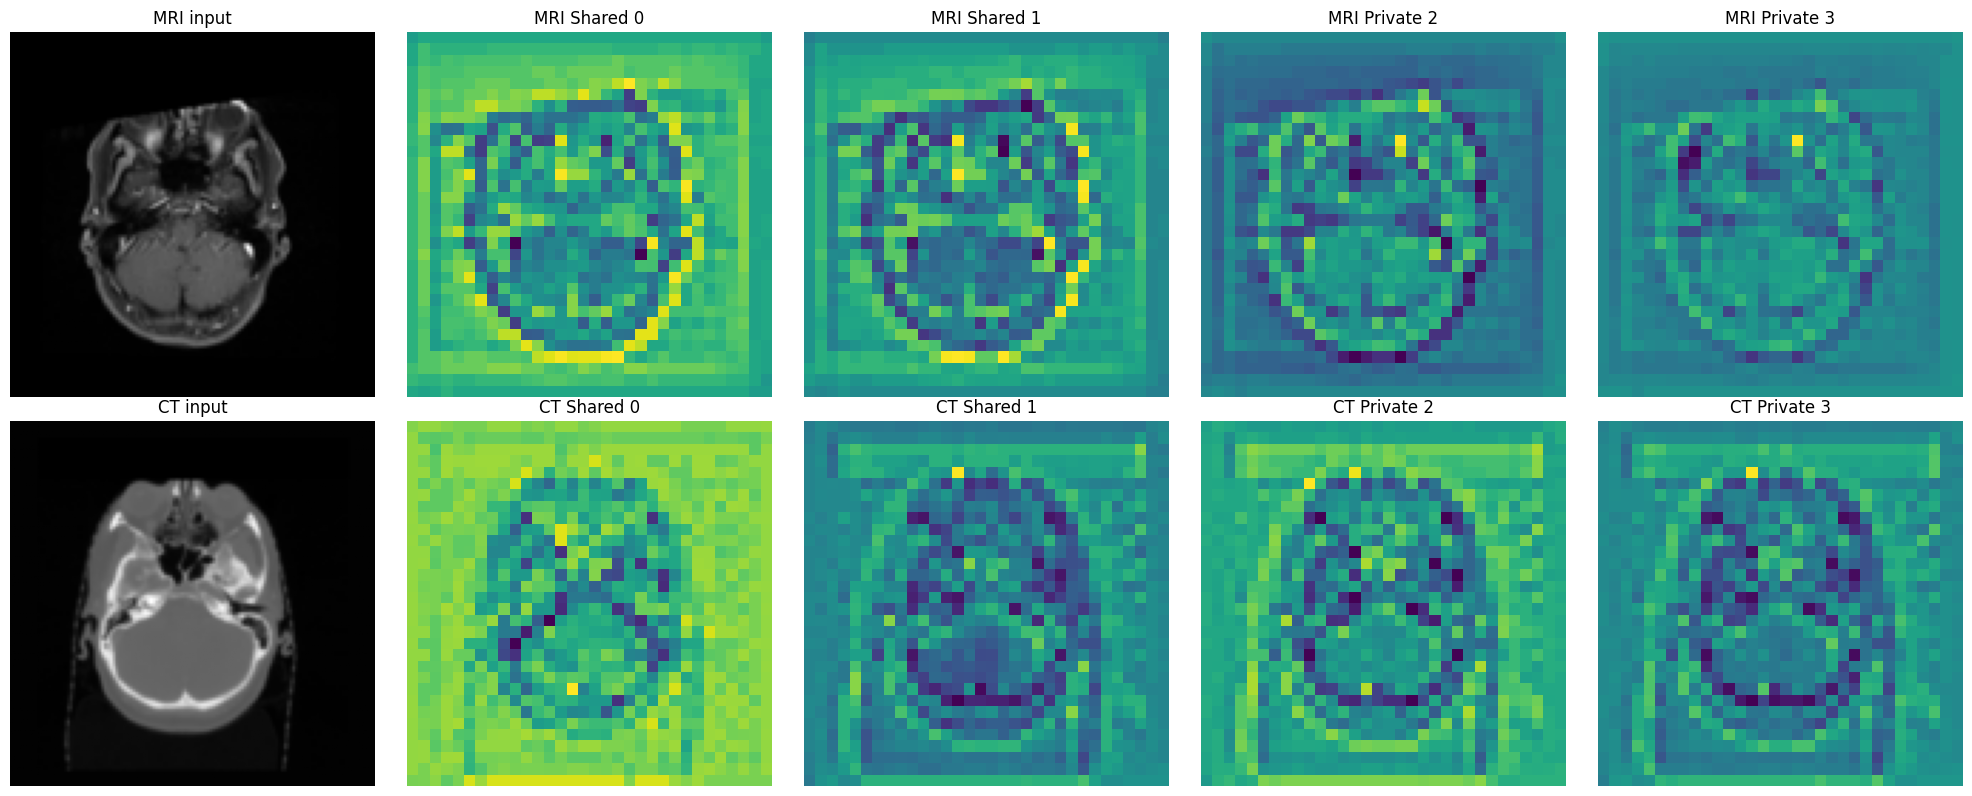

In [21]:
def normalize_for_plot(x):
    x = x.detach().cpu().numpy()

    x_min = x.min()
    x_max = x.max()

    if x_max > x_min:
        x = (x - x_min) / (x_max - x_min)

    return x


fig, axes = plt.subplots(
    2,
    C + 1,
    figsize=(4 * (C + 1), 8)
)

# -------------------------------------------------------
# Original images
# -------------------------------------------------------

axes[0, 0].imshow(
    mri[sample_idx, 0].cpu(),
    cmap="gray"
)
axes[0, 0].set_title("MRI input")
axes[0, 0].axis("off")

axes[1, 0].imshow(
    ct[sample_idx, 0].cpu(),
    cmap="gray"
)
axes[1, 0].set_title("CT input")
axes[1, 0].axis("off")


# -------------------------------------------------------
# MRI latent channels
# -------------------------------------------------------

for c in range(C):

    latent_map = normalize_for_plot(
        z_mri[sample_idx, c]
    )

    axes[0, c + 1].imshow(
        latent_map,
        cmap="viridis"
    )

    if c < shared_channels:
        title = f"MRI Shared {c}"
    else:
        title = f"MRI Private {c}"

    axes[0, c + 1].set_title(title)
    axes[0, c + 1].axis("off")


# -------------------------------------------------------
# CT latent channels
# -------------------------------------------------------

for c in range(C):

    latent_map = normalize_for_plot(
        z_ct[sample_idx, c]
    )

    axes[1, c + 1].imshow(
        latent_map,
        cmap="viridis"
    )

    if c < shared_channels:
        title = f"CT Shared {c}"
    else:
        title = f"CT Private {c}"

    axes[1, c + 1].set_title(title)
    axes[1, c + 1].axis("off")


plt.tight_layout()
plt.show()

In [ ]:
import argparse
import glob
import os
import pickle

import torch
import torchvision
import yaml
from torch.utils.data.dataloader import DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm

from dataset.celeb_dataset import CelebDataset
from dataset.mnist_dataset import MnistDataset
from models.vqvae import VQVAE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def infer(args, model):
    ######## Read the config file #######
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)

    dataset_config = config['dataset_params']
    autoencoder_config = config['autoencoder_params']
    train_config = config['train_params']


    num_images = train_config['num_samples']
    ngrid = train_config['num_grid_rows']

    idxs = torch.randint(0, len(im_dataset) - 1, (num_images,))
    ims = torch.cat([im_dataset[idx][None, :] for idx in idxs]).float()
    ims = ims.to(device)


    model.eval()

    with torch.no_grad():

        encoded_output, _ = model.encode(ims)
        decoded_output = model.decode(encoded_output)
        encoded_output = torch.clamp(encoded_output, -1., 1.)
        encoded_output = (encoded_output + 1) / 2
        decoded_output = torch.clamp(decoded_output, -1., 1.)
        decoded_output = (decoded_output + 1) / 2
        ims = (ims + 1) / 2

        encoder_grid = make_grid(encoded_output.cpu(), nrow=ngrid)
        decoder_grid = make_grid(decoded_output.cpu(), nrow=ngrid)
        input_grid = make_grid(ims.cpu(), nrow=ngrid)
        encoder_grid = torchvision.transforms.ToPILImage()(encoder_grid)
        decoder_grid = torchvision.transforms.ToPILImage()(decoder_grid)
        input_grid = torchvision.transforms.ToPILImage()(input_grid)

        input_grid.save(os.path.join(train_config['task_name'], 'input_samples.png'))
        encoder_grid.save(os.path.join(train_config['task_name'], 'encoded_samples.png'))
        decoder_grid.save(os.path.join(train_config['task_name'], 'reconstructed_samples.png'))

        if train_config['save_latents']:
            # save Latents (but in a very unoptimized way)
            latent_path = os.path.join(train_config['task_name'], train_config['vqvae_latent_dir_name'])
            latent_fnames = glob.glob(os.path.join(train_config['task_name'], train_config['vqvae_latent_dir_name'],
                                                   '*.pkl'))
            assert len(latent_fnames) == 0, 'Latents already present. Delete all latent files and re-run'
            if not os.path.exists(latent_path):
                os.mkdir(latent_path)
            print('Saving Latents for {}'.format(dataset_config['name']))

            fname_latent_map = {}
            part_count = 0
            count = 0

            for idx, im in enumerate(tqdm(data_loader)):
                encoded_output, _ = model.encode(im.float().to(device))
                fname_latent_map[im_dataset.images[idx]] = encoded_output.cpu()
                # Save latents every 1000 images
                if (count+1) % 1000 == 0:
                    pickle.dump(fname_latent_map, open(os.path.join(latent_path,
                                                                    '{}.pkl'.format(part_count)), 'wb'))
                    part_count += 1
                    fname_latent_map = {}
                count += 1
            if len(fname_latent_map) > 0:
                pickle.dump(fname_latent_map, open(os.path.join(latent_path,
                                                   '{}.pkl'.format(part_count)), 'wb'))
            print('Done saving latents')


if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Arguments for vq vae inference')
    parser.add_argument('--config', dest='config_path',
                        default='config/mnist.yaml', type=str)
    args = parser.parse_args()
    infer(args)

In [ ]:
import torch
import torchvision
import argparse
import yaml
import os
from torchvision.utils import make_grid
from PIL import Image
from tqdm import tqdm
from models.unet_base import Unet
from models.vqvae import VQVAE
from scheduler.linear_noise_scheduler import LinearNoiseScheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    os.mkdir('/content/results')
except OSError as e:
    print("Error:", e)


def sample(model, scheduler, train_config, diffusion_model_config,
               autoencoder_model_config, diffusion_config, dataset_config, vae):
    r"""
    Sample stepwise by going backward one timestep at a time.
    We save the x0 predictions
    """
    #im_size = dataset_config['im_size'] // 2**sum(autoencoder_model_config['down_sample'])
    im_size = 32
    xt = torch.randn((train_config['num_samples'],
                      autoencoder_model_config['z_channels'],
                      im_size,
                      im_size)).to(device)

    save_count = 0
    for i in tqdm(reversed(range(diffusion_config['num_timesteps']))):
        # Get prediction of noise
        noise_pred = model(xt, torch.as_tensor(i).unsqueeze(0).to(device))

        # Use scheduler to get x0 and xt-1
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

        # Save x0
        #ims = torch.clamp(xt, -1., 1.).detach().cpu()
        if False and i == 0:
            # Decode ONLY the final iamge to save time
            ims = vae.decode(xt)
        else:
            ims = xt

        ims = torch.clamp(ims, -1., 1.).detach().cpu()
        ims = (ims + 1) / 2
        grid = make_grid(ims, nrow=train_config['num_grid_rows'])
        img = torchvision.transforms.ToPILImage()(grid)

        if not os.path.exists(os.path.join('/content/results', 'samples')):
            os.mkdir(os.path.join('/content/results', 'samples'))
        img.save(os.path.join('/content/results', 'samples', 'x0_{}.png'.format(i)))
        img.close()


def infer(args, model):
    # Read the config file #
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)
    ########################

    diffusion_config = config['diffusion_params']
    dataset_config = config['dataset_params']
    diffusion_model_config = config['ldm_params']
    autoencoder_model_config = config['autoencoder_params']
    train_config = config['train_params']

    # Create the noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
                                     beta_start=diffusion_config['beta_start'],
                                     beta_end=diffusion_config['beta_end'])

    #model = Unet(im_channels=autoencoder_model_config['z_channels'],
     #            model_config=diffusion_model_config).to(device)
    #model.eval()
    #if os.path.exists(os.path.join(train_config['task_name'],
     #                              train_config['ldm_ckpt_name'])):
      #  print('Loaded unet checkpoint')
     #   model.load_state_dict(torch.load(os.path.join(train_config['task_name'],
      #                                                train_config['ldm_ckpt_name']),
      #                                   map_location=device))

    # Create output directories
    if not os.path.exists(train_config['task_name']):
        os.mkdir(train_config['task_name'])

    vae = VQVAE(im_channels=dataset_config['im_channels'],
                model_config=autoencoder_model_config).to(device)
    vae.eval()

    # Load vae if found
    if os.path.exists(os.path.join(train_config['task_name'],
                                                    train_config['vqvae_autoencoder_ckpt_name'])):
        print('Loaded vae checkpoint')
        vae.load_state_dict(torch.load(os.path.join(train_config['task_name'],
                                                    train_config['vqvae_autoencoder_ckpt_name']),
                                       map_location=device), strict=True)
    with torch.no_grad():
        sample(model, scheduler, train_config, diffusion_model_config,
               autoencoder_model_config, diffusion_config, dataset_config, vae)



parser = argparse.ArgumentParser(description='Arguments for ddpm image generation')
parser.add_argument('--config', dest='config_path',
                    default='/content/config/medical_image.yaml', type=str)

args, unknown = parser.parse_known_args(sys.argv[1:])
infer(args, model)